In [1]:
pip install pandas

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
Using cached tzdata-2026.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   -------------------- ------------------- 2/4 [numpy]
   -------------------- ------------------- 2/4 [numpy]
   -------------------- ------------------- 2/4 [numpy]
   -------------------- ------------------- 2/4 [numpy]
   -------------------- ------------------- 2/4 

In [2]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 3.8 MB/s  0:00:00
Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7.2 MB 2.8 MB/s eta 0:00:03
   ------- ----------------------

In [4]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install ast

  Using cached AST-0.0.2.tar.gz (19 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [19 lines of output]
      Traceback (most recent call last):
        File "c:\Users\Snehasish Ghosh\Documents\projects\Movie prediction\.venv\lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "c:\Users\Snehasish Ghosh\Documents\projects\Movie prediction\.venv\lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
        File "c:\Users\Snehasish Ghosh\Documents\projects\Movie prediction\.venv\lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "C:\Users\Snehasish Ghosh\AppData\Local\Temp\pip-build-env-x3xivwg5\overlay\Lib\site-packages\setuptools\build_meta.py", line

In [6]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('tmdb_5000_movies.csv')

# 1. Handle JSON-like string columns
# Helper function to extract 'name' from the JSON strings
def extract_names(json_str):
    if pd.isna(json_str) or json_str == '[]':
        return []
    try:
        return [i['name'] for i in ast.literal_eval(json_str)]
    except (ValueError, TypeError):
        return []

# Apply to relevant columns
json_cols = ['genres', 'keywords', 'production_companies', 'production_countries', 'spoken_languages']
for col in json_cols:
    df[col] = df[col].apply(extract_names)

# 2. Handle Missing Values
# Fill text nulls with empty strings
df['tagline'].fillna('', inplace=True)
df['overview'].fillna('', inplace=True)
df['homepage'].fillna('', inplace=True)

# Drop rows with missing release dates or runtimes (crucial for temporal/numerical analysis)
df.dropna(subset=['release_date', 'runtime'], inplace=True)

# 3. Convert Data Types
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

# 4. Filter out unreleased or zero-budget movies (Noise reduction)
df = df[df['status'] == 'Released']
df = df[df['budget'] > 0] # 0 budget usually means missing data
df = df[df['revenue'] > 0] 

C:\Users\Snehasish Ghosh\AppData\Local\Temp\ipykernel_11184\691547217.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tagline'].fillna('', inplace=True)
C:\Users\Snehasish Ghosh\AppData\Local\Temp\ipykernel_11184\691547217.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [7]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('tmdb_5000_movies.csv')


# 1. Handle JSON-like string columns
def extract_names(json_str):
    if pd.isna(json_str) or json_str == '[]':
        return []

    try:
        return [i['name'] for i in ast.literal_eval(json_str)]
    except (ValueError, TypeError):
        return []


json_cols = [
    'genres',
    'keywords',
    'production_companies',
    'production_countries',
    'spoken_languages'
]

for col in json_cols:
    df[col] = df[col].apply(extract_names)


# 2. Handle Missing Values
df['tagline'] = df['tagline'].fillna('')
df['overview'] = df['overview'].fillna('')
df['homepage'] = df['homepage'].fillna('')

df.dropna(
    subset=['release_date', 'runtime'],
    inplace=True
)


# 3. Convert Data Types
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year


# 4. Filter data
df = df[df['status'] == 'Released']
df = df[df['budget'] > 0]
df = df[df['revenue'] > 0]

# Make an independent copy
df = df.copy()

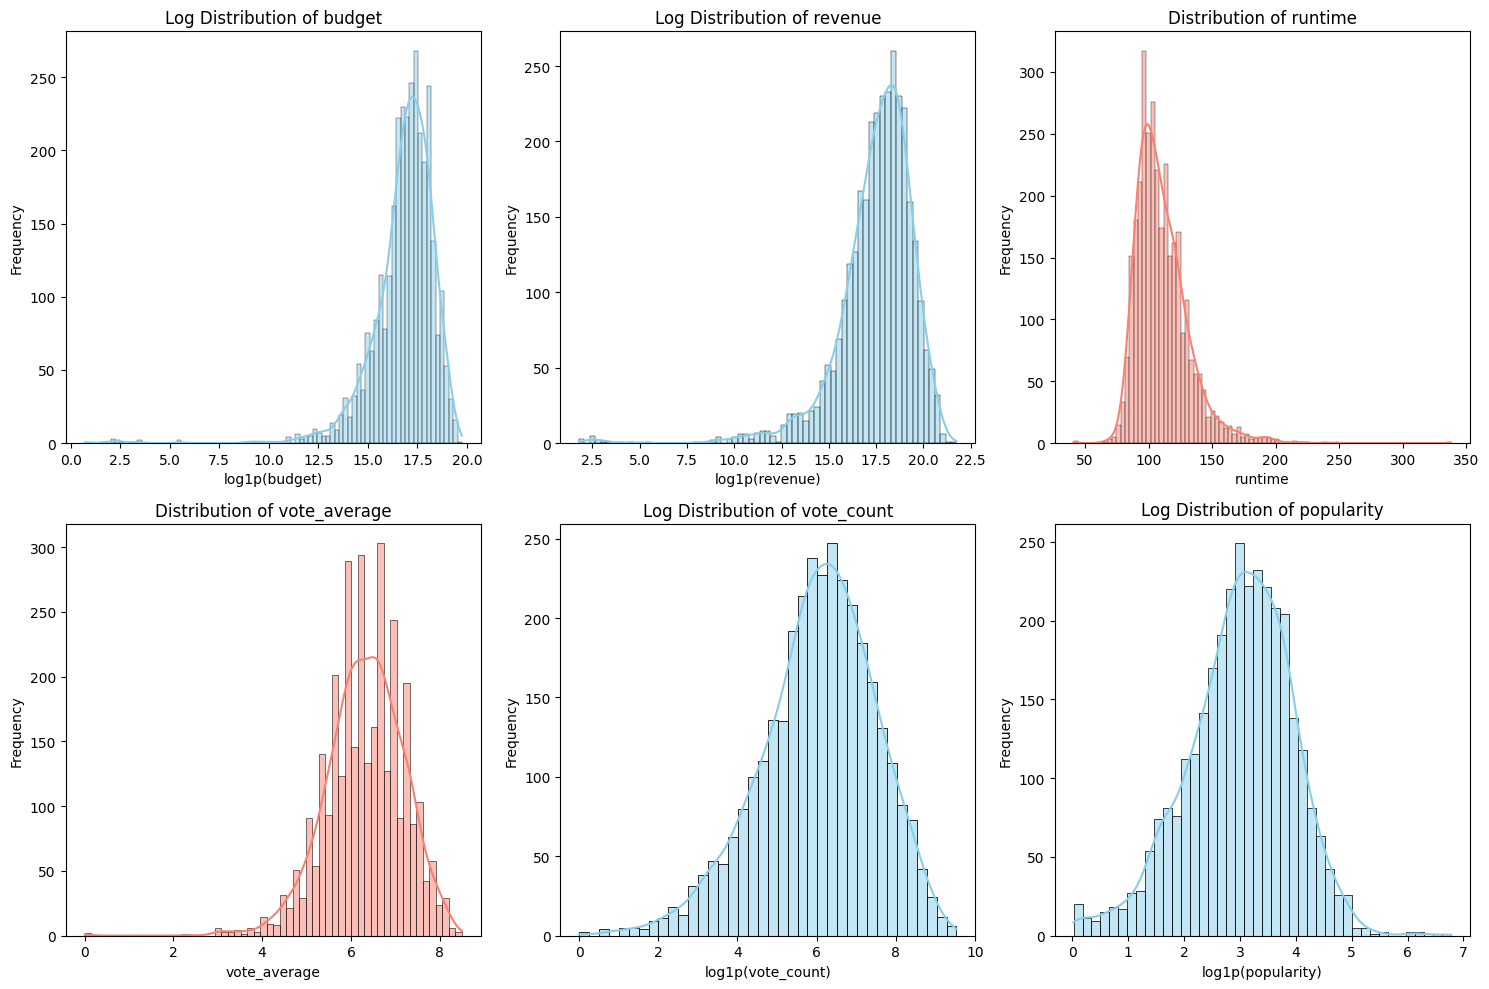

In [8]:
num_cols = [
    'budget',
    'revenue',
    'runtime',
    'vote_average',
    'vote_count',
    'popularity'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    # Apply log transformation to highly skewed variables
    if col in ['budget', 'revenue', 'vote_count', 'popularity']:

        sns.histplot(
            np.log1p(df[col]),
            ax=axes[i],
            kde=True,
            color='skyblue'
        )

        axes[i].set_title(f'Log Distribution of {col}')
        axes[i].set_xlabel(f'log1p({col})')
        axes[i].set_ylabel('Frequency')

    else:

        sns.histplot(
            df[col],
            ax=axes[i],
            kde=True,
            color='salmon'
        )

        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

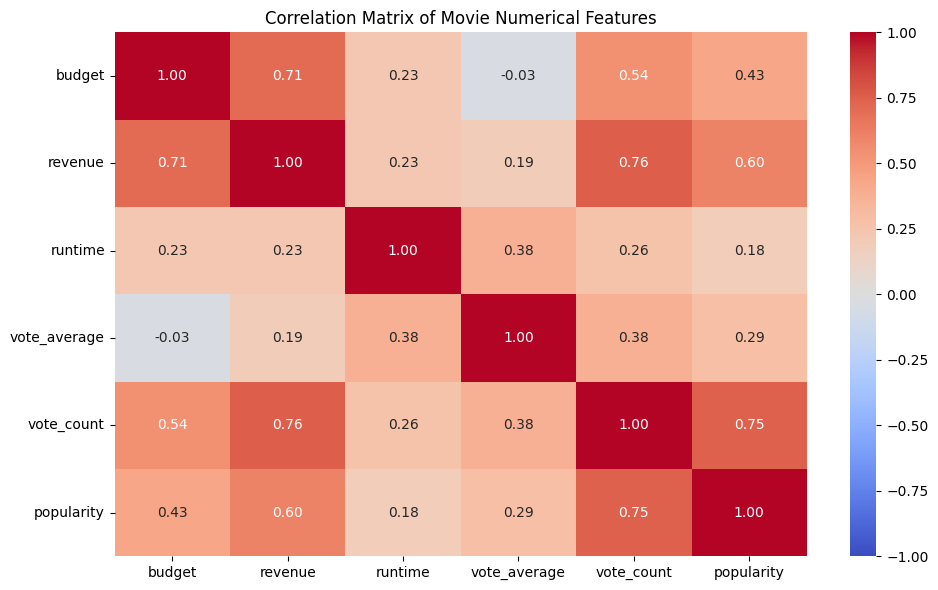

In [9]:
plt.figure(figsize=(10, 6))

# Calculate the correlation matrix
corr_matrix = df[num_cols].corr()

# Plot the correlation matrix as a heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix of Movie Numerical Features')
plt.tight_layout()
plt.show()

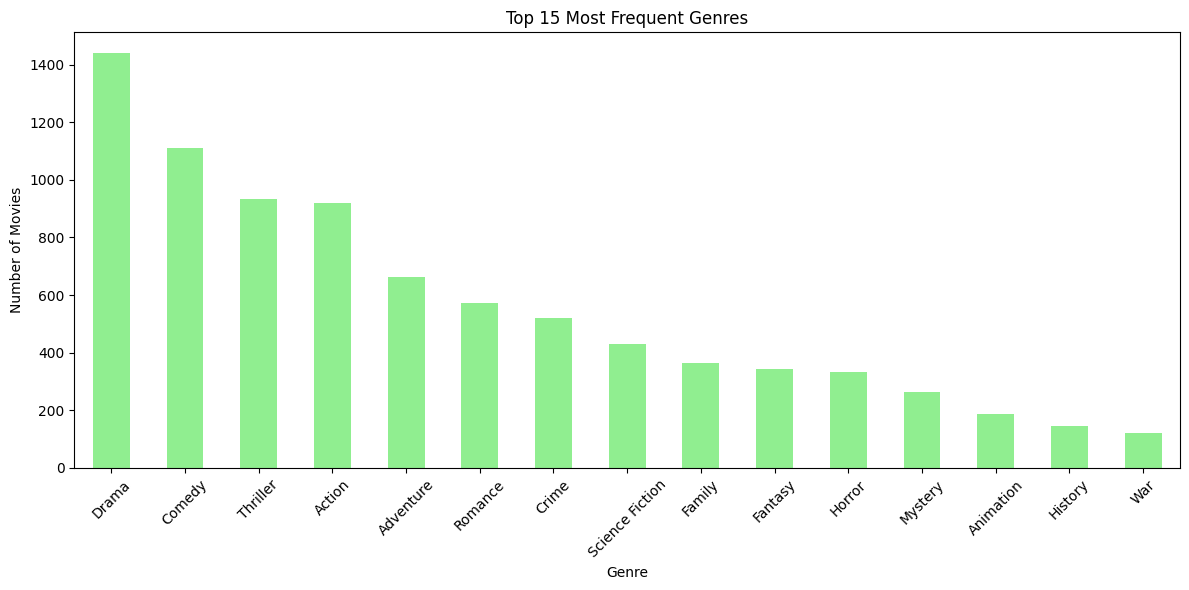

In [10]:
# Explode the genres list so that each genre gets its own row
all_genres = df.explode('genres')

plt.figure(figsize=(12, 6))

# Count the frequency of each genre and select the top 15
genre_counts = all_genres['genres'].value_counts().head(15)

# Plot the top 15 genres
genre_counts.plot(
    kind='bar',
    color='lightgreen'
)

plt.title('Top 15 Most Frequent Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

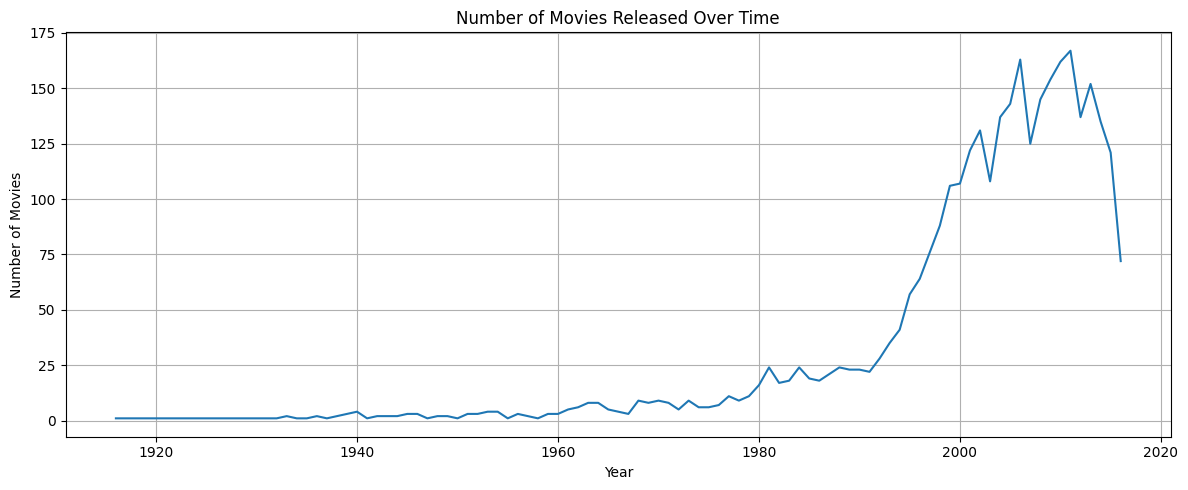

In [11]:
# Count the number of movies released in each year
movies_per_year = df.groupby('release_year').size()

plt.figure(figsize=(12, 5))

# Plot the number of movies released over time
movies_per_year.plot(
    kind='line'
)

plt.title('Number of Movies Released Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# Calculate C: mean vote across all movies
C = df['vote_average'].mean()

# Calculate m: minimum number of votes required to qualify
# Here, m is set to the 90th percentile of vote_count
m = df['vote_count'].quantile(0.90)

# Keep only movies that have at least m votes
q_movies = df.loc[df['vote_count'] >= m].copy()


# Calculate the weighted rating for each movie
def weighted_rating(x, m=m, C=C):

    v = x['vote_count']
    R = x['vote_average']

    return (
        (v / (v + m)) * R
        + (m / (v + m)) * C
    )


# Apply the weighted-rating formula to every movie
q_movies['score'] = q_movies.apply(
    weighted_rating,
    axis=1
)


# Add the calculated scores back to the original DataFrame
df = df.merge(
    q_movies[['id', 'score']],
    on='id',
    how='left'
)

In [13]:
%pip install nltk

  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------- ---------------------- 0.8/1.8 MB 4.8 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 3.1 MB/s  0:00:00
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)

   ------ --------------------------------- 1/6 [regex]
   ------------- -------------------------- 2/6 [joblib]
   -------------------------- ------------- 4/6 [click]
   --------------------------------- ------ 5/6 [nltk]
   --------------------------------- ------ 5/6 [nltk]
   --------------------------------- ------ 5/6 [nltk]
   --------------------------------- ------ 5/6 [nltk]
   --------------------------------- ------ 5/6 [nltk]
   --------------

In [16]:
%pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- ------------------

In [17]:
import re
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the stemmer
stemmer = PorterStemmer()


# Clean and normalize text
def clean_text(text):

    # Remove special characters and convert text to lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text).lower()

    # Split the text into individual words
    words = text.split()

    # Apply stemming to each word
    words = [stemmer.stem(word) for word in words]

    # Join the words back into a single string
    return ' '.join(words)


# Convert genre lists into space-separated strings
# Multi-word genres are joined together
df['genres_str'] = df['genres'].apply(
    lambda x: ' '.join(
        genre.replace(' ', '')
        for genre in x
    )
)


# Convert keyword lists into space-separated strings
# Multi-word keywords are joined together
df['keywords_str'] = df['keywords'].apply(
    lambda x: ' '.join(
        keyword.replace(' ', '')
        for keyword in x
    )
)


# Combine all text-based movie information
df['soup'] = (
    df['overview']
    + ' '
    + df['tagline']
    + ' '
    + df['genres_str']
    + ' '
    + df['keywords_str']
)


# Clean and normalize the combined text
df['soup'] = df['soup'].apply(clean_text)

In [18]:
# Find the 10 most frequent genres
top_genres = (
    all_genres['genres']
    .value_counts()
    .head(10)
    .index
    .tolist()
)


# Create a binary column for each of the top 10 genres
for genre in top_genres:

    df[f'genre_{genre}'] = df['genres'].apply(
        lambda genres: 1 if genre in genres else 0
    )

In [19]:
# Count the number of production companies for each movie
df['num_production_companies'] = df['production_companies'].apply(len)

# Count the number of production countries for each movie
df['num_countries'] = df['production_countries'].apply(len)

# Count the number of spoken languages for each movie
df['num_spoken_languages'] = df['spoken_languages'].apply(len)

In [20]:
# Create a TF-IDF vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

# Convert the movie metadata into a TF-IDF matrix
tfidf_matrix = tfidf.fit_transform(df['soup'])

In [21]:
from sklearn.feature_extraction.text import CountVectorizer


# Create a Count Vectorizer
count = CountVectorizer(
    stop_words='english',
    max_features=5000
)


# Convert the movie metadata into a word-count matrix
count_matrix = count.fit_transform(df['soup'])

In [22]:
from sklearn.preprocessing import MinMaxScaler


# Select numerical features for the recommendation system
numerical_features = df[
    [
        'score',
        'runtime',
        'budget',
        'revenue',
        'num_production_companies',
        'num_countries',
        'num_spoken_languages'
    ]
].fillna(0)


# Create the scaler
scaler = MinMaxScaler()


# Normalize numerical features to the range 0–1
scaled_numerical = scaler.fit_transform(numerical_features)

print('Scaled Numerical Matrix Shape:', scaled_numerical.shape)

Scaled Numerical Matrix Shape: (3228, 7)


In [23]:
from sklearn.metrics.pairwise import cosine_similarity


# Calculate cosine similarity between all movies
cosine_sim = cosine_similarity(tfidf_matrix)

print('Cosine Similarity Matrix Shape:', cosine_sim.shape)

Cosine Similarity Matrix Shape: (3228, 3228)


In [24]:
# Create a mapping from movie title to its row index
indices = pd.Series(
    df.index,
    index=df['title']
).drop_duplicates()

print(indices.head())

title
Avatar                                      0
Pirates of the Caribbean: At World's End    1
Spectre                                     2
The Dark Knight Rises                       3
John Carter                                 4
dtype: int64


In [25]:
def get_recommendations(title, cosine_sim=cosine_sim):

    # Find the index of the movie
    idx = indices[title]

    # Get similarity scores for this movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort movies by similarity score
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Get the top 10 most similar movies
    sim_scores = sim_scores[1:11]

    # Get the DataFrame indices of those movies
    movie_indices = [i[0] for i in sim_scores]

    # Return the movie titles
    return df['title'].iloc[movie_indices]

In [26]:
get_recommendations('Avatar')

2046                                        Aliens
519                                     Titan A.E.
740                                      Meet Dave
2786                                     Apollo 18
47                         Star Trek Into Darkness
363     Lara Croft Tomb Raider: The Cradle of Life
489                               Independence Day
1118                                     Predators
1012                           Aliens in the Attic
1227                          The Inhabited Island
Name: title, dtype: object

In [27]:
# Get the names of the engineered genre columns
genre_columns = [
    col for col in df.columns
    if col.startswith('genre_')
]

# Extract the genre features
genre_matrix = df[genre_columns].values

print('Genre Matrix Shape:', genre_matrix.shape)

Genre Matrix Shape: (3228, 10)


In [28]:
from scipy.sparse import hstack

# Give genre features additional importance
genre_weight = 2.0

# Combine TF-IDF text features with weighted genre features
combined_matrix = hstack([
    tfidf_matrix,
    genre_matrix * genre_weight
])

print('Combined Feature Matrix Shape:', combined_matrix.shape)

Combined Feature Matrix Shape: (3228, 10010)


In [29]:
cosine_sim_genre = cosine_similarity(combined_matrix)

print(
    'Genre-Enhanced Cosine Similarity Matrix Shape:',
    cosine_sim_genre.shape
)

Genre-Enhanced Cosine Similarity Matrix Shape: (3228, 3228)


In [30]:
def get_recommendations(title, similarity_matrix):

    # Find the index of the selected movie
    idx = indices[title]

    # Get similarity scores for the selected movie
    sim_scores = list(enumerate(similarity_matrix[idx]))

    # Sort by similarity score from highest to lowest
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the movie itself and keep the top 10
    sim_scores = sim_scores[1:11]

    # Extract movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return movie titles
    return df['title'].iloc[movie_indices]

In [31]:
get_recommendations('Avatar', cosine_sim)

2046                                        Aliens
519                                     Titan A.E.
740                                      Meet Dave
2786                                     Apollo 18
47                         Star Trek Into Darkness
363     Lara Croft Tomb Raider: The Cradle of Life
489                               Independence Day
1118                                     Predators
1012                           Aliens in the Attic
1227                          The Inhabited Island
Name: title, dtype: object

In [32]:
get_recommendations('Avatar', cosine_sim_genre)

61                              Jupiter Ascending
46                     X-Men: Days of Future Past
14                                   Man of Steel
821                                   Superman II
230                                 The Wolverine
770                                      Superman
2724    Beastmaster 2: Through the Portal of Time
10                               Superman Returns
317                             The Fifth Element
1108                               Small Soldiers
Name: title, dtype: object

In [33]:
# Numerical features that are highly right-skewed
log_features = [
    'budget',
    'revenue',
    'num_production_companies',
    'num_countries',
    'num_spoken_languages'
]

# Create a copy of the numerical features
numerical_features_improved = df[
    [
        'score',
        'runtime',
        'budget',
        'revenue',
        'num_production_companies',
        'num_countries',
        'num_spoken_languages'
    ]
].copy()

# Apply log transformation to skewed features
for col in log_features:
    numerical_features_improved[col] = np.log1p(
        numerical_features_improved[col]
    )

# Normalize all numerical features to 0–1
numerical_scaler = MinMaxScaler()

scaled_numerical_improved = numerical_scaler.fit_transform(
    numerical_features_improved
)

print(
    'Improved Numerical Matrix Shape:',
    scaled_numerical_improved.shape
)

Improved Numerical Matrix Shape: (3228, 7)


In [34]:
from scipy.sparse import csr_matrix, hstack

# Give numerical features a smaller initial weight
numerical_weight = 0.5

# Convert numerical features to a sparse matrix
numerical_matrix_sparse = csr_matrix(
    scaled_numerical_improved * numerical_weight
)

# Combine text, genre, and numerical features
full_feature_matrix = hstack([
    combined_matrix,
    numerical_matrix_sparse
])

print(
    'Full Feature Matrix Shape:',
    full_feature_matrix.shape
)

Full Feature Matrix Shape: (3228, 10017)


In [36]:
# Calculate cosine similarity using
# TF-IDF + genre + numerical features
cosine_sim_full = cosine_similarity(full_feature_matrix)

print(
    'Full Feature Cosine Similarity Matrix Shape:',
    cosine_sim_full.shape
)

ValueError: Input contains NaN.

In [37]:
print(numerical_features_improved.isna().sum())

score                       2904
runtime                        0
budget                         0
revenue                        0
num_production_companies       0
num_countries                  0
num_spoken_languages           0
dtype: int64


In [38]:
# Fill the weighted score of non-qualified movies
# with the overall mean rating
df['score'] = df['score'].fillna(C)

print('Missing scores:', df['score'].isna().sum())

Missing scores: 0


In [39]:
# Numerical features that are highly right-skewed
log_features = [
    'budget',
    'revenue',
    'num_production_companies',
    'num_countries',
    'num_spoken_languages'
]

# Create a fresh copy of the numerical features
numerical_features_improved = df[
    [
        'score',
        'runtime',
        'budget',
        'revenue',
        'num_production_companies',
        'num_countries',
        'num_spoken_languages'
    ]
].copy()

# Apply log transformation to skewed features
for col in log_features:
    numerical_features_improved[col] = np.log1p(
        numerical_features_improved[col]
    )

# Normalize numerical features
numerical_scaler = MinMaxScaler()

scaled_numerical_improved = numerical_scaler.fit_transform(
    numerical_features_improved
)

print(
    'Improved Numerical Matrix Shape:',
    scaled_numerical_improved.shape
)

Improved Numerical Matrix Shape: (3228, 7)


In [40]:
from scipy.sparse import csr_matrix, hstack

# Weight assigned to numerical features
numerical_weight = 0.5

# Convert numerical features to a sparse matrix
numerical_matrix_sparse = csr_matrix(
    scaled_numerical_improved * numerical_weight
)

# Combine TF-IDF + genre + numerical features
full_feature_matrix = hstack([
    combined_matrix,
    numerical_matrix_sparse
])

print(
    'Full Feature Matrix Shape:',
    full_feature_matrix.shape
)

Full Feature Matrix Shape: (3228, 10017)


In [41]:
# Calculate cosine similarity using
# TF-IDF + genre + numerical features
cosine_sim_full = cosine_similarity(full_feature_matrix)

print(
    'Full Feature Cosine Similarity Matrix Shape:',
    cosine_sim_full.shape
)

Full Feature Cosine Similarity Matrix Shape: (3228, 3228)


In [42]:
get_recommendations('Avatar', cosine_sim_full)

46                     X-Men: Days of Future Past
14                                   Man of Steel
61                              Jupiter Ascending
821                                   Superman II
230                                 The Wolverine
10                               Superman Returns
770                                      Superman
2724    Beastmaster 2: Through the Portal of Time
317                             The Fifth Element
1108                               Small Soldiers
Name: title, dtype: object

In [43]:
def compare_models(title):

    print(f'\n{"=" * 60}')
    print(f'Recommendations for: {title}')
    print(f'{"=" * 60}')

    print('\nMODEL 1 — TF-IDF')
    print(get_recommendations(title, cosine_sim).to_string(index=False))

    print('\nMODEL 2 — TF-IDF + GENRES')
    print(get_recommendations(title, cosine_sim_genre).to_string(index=False))

    print('\nMODEL 3 — TF-IDF + GENRES + NUMERICAL')
    print(get_recommendations(title, cosine_sim_full).to_string(index=False))

In [44]:
compare_models('The Dark Knight')


Recommendations for: The Dark Knight

MODEL 1 — TF-IDF
             The Dark Knight Rises
                    Batman Returns
                     Batman Begins
                            Batman
                    Batman Forever
Batman v Superman: Dawn of Justice
                    Batman & Robin
               Law Abiding Citizen
                          Defendor
Sherlock Holmes: A Game of Shadows

MODEL 2 — TF-IDF + GENRES
The Dark Knight Rises
          Harsh Times
   The Way of the Gun
               Hitman
          Point Blank
       3 Days to Kill
              Shooter
               Takers
           Contraband
                Drive

MODEL 3 — TF-IDF + GENRES + NUMERICAL
The Dark Knight Rises
                Drive
             Scarface
               Hitman
       3 Days to Kill
              Shooter
          Harsh Times
           Contraband
           Colombiana
              Payback


In [45]:
# Convert additional metadata lists into text strings
df['companies_str'] = df['production_companies'].apply(
    lambda x: ' '.join(company.replace(' ', '') for company in x)
)

df['countries_str'] = df['production_countries'].apply(
    lambda x: ' '.join(country.replace(' ', '') for country in x)
)

df['languages_str'] = df['spoken_languages'].apply(
    lambda x: ' '.join(language.replace(' ', '') for language in x)
)


# Create an expanded metadata soup
df['expanded_soup'] = (
    df['overview']
    + ' '
    + df['tagline']
    + ' '
    + df['genres_str']
    + ' '
    + df['keywords_str']
    + ' '
    + df['companies_str']
    + ' '
    + df['countries_str']
    + ' '
    + df['languages_str']
)


# Clean the expanded soup
df['expanded_soup'] = df['expanded_soup'].apply(clean_text)

print('Expanded metadata soup created successfully.')

Expanded metadata soup created successfully.


In [46]:
# Create a new TF-IDF vectorizer for the expanded metadata
tfidf_expanded = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

# Convert expanded movie metadata into TF-IDF vectors
tfidf_matrix_expanded = tfidf_expanded.fit_transform(
    df['expanded_soup']
)

print(
    'Expanded TF-IDF Matrix Shape:',
    tfidf_matrix_expanded.shape
)

Expanded TF-IDF Matrix Shape: (3228, 10000)


In [47]:
# Calculate cosine similarity using the expanded metadata
cosine_sim_expanded = cosine_similarity(tfidf_matrix_expanded)

print(
    'Expanded TF-IDF Cosine Similarity Matrix Shape:',
    cosine_sim_expanded.shape
)

Expanded TF-IDF Cosine Similarity Matrix Shape: (3228, 3228)


In [48]:
get_recommendations('Avatar', cosine_sim_expanded)

2046                                        Aliens
740                                      Meet Dave
519                                     Titan A.E.
1118                                     Predators
798                                      The Watch
2786                                     Apollo 18
489                               Independence Day
1012                           Aliens in the Attic
363     Lara Croft Tomb Raider: The Cradle of Life
1127                   Aliens vs Predator: Requiem
Name: title, dtype: object

In [49]:
get_recommendations('Avatar', cosine_sim_expanded)

2046                                        Aliens
740                                      Meet Dave
519                                     Titan A.E.
1118                                     Predators
798                                      The Watch
2786                                     Apollo 18
489                               Independence Day
1012                           Aliens in the Attic
363     Lara Croft Tomb Raider: The Cradle of Life
1127                   Aliens vs Predator: Requiem
Name: title, dtype: object

In [50]:
compare_models('The Dark Knight')


Recommendations for: The Dark Knight

MODEL 1 — TF-IDF
             The Dark Knight Rises
                    Batman Returns
                     Batman Begins
                            Batman
                    Batman Forever
Batman v Superman: Dawn of Justice
                    Batman & Robin
               Law Abiding Citizen
                          Defendor
Sherlock Holmes: A Game of Shadows

MODEL 2 — TF-IDF + GENRES
The Dark Knight Rises
          Harsh Times
   The Way of the Gun
               Hitman
          Point Blank
       3 Days to Kill
              Shooter
               Takers
           Contraband
                Drive

MODEL 3 — TF-IDF + GENRES + NUMERICAL
The Dark Knight Rises
                Drive
             Scarface
               Hitman
       3 Days to Kill
              Shooter
          Harsh Times
           Contraband
           Colombiana
              Payback


In [51]:
def compare_all_models(title):

    print(f'\n{"=" * 60}')
    print(f'Recommendations for: {title}')
    print(f'{"=" * 60}')

    print('\nMODEL 1 — ORIGINAL TF-IDF')
    print(get_recommendations(title, cosine_sim).to_string(index=False))

    print('\nMODEL 2 — TF-IDF + GENRES')
    print(get_recommendations(title, cosine_sim_genre).to_string(index=False))

    print('\nMODEL 3 — TF-IDF + GENRES + NUMERICAL')
    print(get_recommendations(title, cosine_sim_full).to_string(index=False))

    print('\nMODEL 4 — EXPANDED TF-IDF')
    print(get_recommendations(title, cosine_sim_expanded).to_string(index=False))

In [52]:
compare_all_models('The Dark Knight')


Recommendations for: The Dark Knight

MODEL 1 — ORIGINAL TF-IDF
             The Dark Knight Rises
                    Batman Returns
                     Batman Begins
                            Batman
                    Batman Forever
Batman v Superman: Dawn of Justice
                    Batman & Robin
               Law Abiding Citizen
                          Defendor
Sherlock Holmes: A Game of Shadows

MODEL 2 — TF-IDF + GENRES
The Dark Knight Rises
          Harsh Times
   The Way of the Gun
               Hitman
          Point Blank
       3 Days to Kill
              Shooter
               Takers
           Contraband
                Drive

MODEL 3 — TF-IDF + GENRES + NUMERICAL
The Dark Knight Rises
                Drive
             Scarface
               Hitman
       3 Days to Kill
              Shooter
          Harsh Times
           Contraband
           Colombiana
              Payback

MODEL 4 — EXPANDED TF-IDF
             The Dark Knight Rises
                 

In [53]:
def get_weighted_recommendations(title, genre_weight, top_n=10):

    # Combine TF-IDF with the chosen genre weight
    weighted_features = hstack([
        tfidf_matrix,
        genre_matrix * genre_weight
    ])

    # Find the selected movie's index
    idx = indices[title]

    # Calculate similarity of this movie against all movies
    movie_similarity = cosine_similarity(
        weighted_features[idx],
        weighted_features
    ).flatten()

    # Get indices sorted from highest to lowest similarity
    similar_indices = movie_similarity.argsort()[::-1]

    # Remove the movie itself
    similar_indices = [
        i for i in similar_indices
        if i != idx
    ]

    # Return the top recommendations
    return df['title'].iloc[
        similar_indices[:top_n]
    ]

In [54]:
genre_weights = [0.5, 1.0, 1.5, 2.0, 3.0]

for weight in genre_weights:

    print(f'\n{"=" * 50}')
    print(f'GENRE WEIGHT: {weight}')
    print(f'{"=" * 50}')

    recommendations = get_weighted_recommendations(
        'Avatar',
        genre_weight=weight
    )

    print(recommendations.to_string(index=False))


GENRE WEIGHT: 0.5


TypeError: 'coo_matrix' object is not subscriptable

In [55]:
from scipy.sparse import csr_matrix, hstack


def get_weighted_recommendations(title, genre_weight, top_n=10):

    # Combine TF-IDF with the selected genre weight
    weighted_features = hstack([
        tfidf_matrix,
        genre_matrix * genre_weight
    ]).tocsr()

    # Find the index of the selected movie
    idx = indices[title]

    # Calculate similarity between the selected movie
    # and every movie in the dataset
    movie_similarity = cosine_similarity(
        weighted_features[idx],
        weighted_features
    ).flatten()

    # Sort movie indices by similarity score
    similar_indices = movie_similarity.argsort()[::-1]

    # Remove the selected movie itself
    similar_indices = [
        i for i in similar_indices
        if i != idx
    ]

    # Return the top recommendations
    return df['title'].iloc[
        similar_indices[:top_n]
    ]

In [56]:
genre_weights = [0.5, 1.0, 1.5, 2.0, 3.0]

for weight in genre_weights:

    print(f'\n{"=" * 50}')
    print(f'GENRE WEIGHT: {weight}')
    print(f'{"=" * 50}')

    recommendations = get_weighted_recommendations(
        'Avatar',
        genre_weight=weight
    )

    print(recommendations.to_string(index=False))


GENRE WEIGHT: 0.5
                        Jupiter Ascending
               X-Men: Days of Future Past
                             Man of Steel
                              Superman II
                        The Fifth Element
                            The Wolverine
                                 Superman
Beastmaster 2: Through the Portal of Time
                         Superman Returns
                           Small Soldiers

GENRE WEIGHT: 1.0
                        Jupiter Ascending
               X-Men: Days of Future Past
                             Man of Steel
                              Superman II
                            The Wolverine
                                 Superman
Beastmaster 2: Through the Portal of Time
                         Superman Returns
                        The Fifth Element
                           Small Soldiers

GENRE WEIGHT: 1.5
                        Jupiter Ascending
               X-Men: Days of Future Past
                   

In [57]:
test_movies = [
    'Avatar',
    'The Dark Knight',
    'Toy Story',
    'The Godfather',
    'Titanic'
]

for movie in test_movies:

    print(f'\n{"=" * 60}')
    print(f'{movie}')
    print(f'{"=" * 60}')

    print('\nTF-IDF:')
    print(
        get_recommendations(
            movie,
            cosine_sim
        ).to_string(index=False)
    )

    print('\nTF-IDF + Genres:')
    print(
        get_recommendations(
            movie,
            cosine_sim_genre
        ).to_string(index=False)
    )


Avatar

TF-IDF:
                                    Aliens
                                Titan A.E.
                                 Meet Dave
                                 Apollo 18
                   Star Trek Into Darkness
Lara Croft Tomb Raider: The Cradle of Life
                          Independence Day
                                 Predators
                       Aliens in the Attic
                      The Inhabited Island

TF-IDF + Genres:
                        Jupiter Ascending
               X-Men: Days of Future Past
                             Man of Steel
                              Superman II
                            The Wolverine
                                 Superman
Beastmaster 2: Through the Portal of Time
                         Superman Returns
                        The Fifth Element
                           Small Soldiers

The Dark Knight

TF-IDF:
             The Dark Knight Rises
                    Batman Returns
                   

In [58]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity using genre features only
genre_similarity = cosine_similarity(genre_matrix)

print(
    'Genre Similarity Matrix Shape:',
    genre_similarity.shape
)

Genre Similarity Matrix Shape: (3228, 3228)


In [59]:
# Define the contribution of each similarity component
text_weight = 0.80
genre_weight = 0.20


# Combine text and genre similarity
final_similarity = (
    text_weight * cosine_sim
    + genre_weight * genre_similarity
)


print(
    'Final Similarity Matrix Shape:',
    final_similarity.shape
)

Final Similarity Matrix Shape: (3228, 3228)


In [60]:
def recommend_movies(title, similarity_matrix, top_n=10):

    # Find the index of the selected movie
    idx = indices[title]

    # Get similarity scores for all movies
    sim_scores = list(enumerate(similarity_matrix[idx]))

    # Sort by similarity score from highest to lowest
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected movie itself
    sim_scores = sim_scores[1:top_n + 1]

    # Get movie indices and similarity scores
    movie_indices = [i[0] for i in sim_scores]
    similarity_scores = [i[1] for i in sim_scores]

    # Create the recommendation table
    recommendations = df.iloc[movie_indices][
        ['title']
    ].copy()

    recommendations['similarity_score'] = similarity_scores

    # Reset the index for cleaner output
    recommendations = recommendations.reset_index(drop=True)

    return recommendations

In [61]:
recommend_movies('Avatar', final_similarity)

,title,similarity_score
0,Star Trek Into Darkness,0.265582
1,Independence Day,0.265347
2,Ender's Game,0.258505
3,The Fifth Element,0.256696
4,Titan A.E.,0.255816
5,Jupiter Ascending,0.255153
6,X-Men: Days of Future Past,0.252424
7,The Time Machine,0.246313
8,Independence Day: Resurgence,0.245161
9,Lara Croft Tomb Raider: The Cradle of Life,0.242349


In [62]:
weights = [
    (0.90, 0.10),
    (0.80, 0.20),
    (0.70, 0.30),
    (0.60, 0.40)
]

for text_weight, genre_weight in weights:

    final_similarity_test = (
        text_weight * cosine_sim
        + genre_weight * genre_similarity
    )

    print(f'\n{"=" * 60}')
    print(
        f'Text: {text_weight:.0%} | '
        f'Genre: {genre_weight:.0%}'
    )
    print(f'{"=" * 60}')

    print(
        recommend_movies(
            'Avatar',
            final_similarity_test
        ).to_string(index=False)
    )


Text: 90% | Genre: 10%
                                     title  similarity_score
                                Titan A.E.          0.194043
                   Star Trek Into Darkness          0.190527
                          Independence Day          0.190262
                                    Aliens          0.183910
                              Ender's Game          0.182565
Lara Croft Tomb Raider: The Cradle of Life          0.178892
                                 Predators          0.178014
                         The Fifth Element          0.176980
                      The Inhabited Island          0.172041
                          The Time Machine          0.168849

Text: 80% | Genre: 20%
                                     title  similarity_score
                   Star Trek Into Darkness          0.265582
                          Independence Day          0.265347
                              Ender's Game          0.258505
                         The Fifth El

In [63]:
final_similarity_80_20 = (
    0.80 * cosine_sim
    + 0.20 * genre_similarity
)

test_movies = [
    'The Dark Knight',
    'Toy Story',
    'The Godfather',
    'Titanic'
]

for movie in test_movies:

    print(f'\n{"=" * 60}')
    print(f'Recommendations for: {movie}')
    print(f'{"=" * 60}')

    print(
        recommend_movies(
            movie,
            final_similarity_80_20
        ).to_string(index=False)
    )


Recommendations for: The Dark Knight
                title  similarity_score
The Dark Knight Rises          0.517663
        Batman Begins          0.396079
       Batman Returns          0.351137
       Batman Forever          0.317117
       Batman & Robin          0.278682
  Law Abiding Citizen          0.276287
               Batman          0.275263
            Slow Burn          0.266033
          Harsh Times          0.254652
   The Way of the Gun          0.250854

Recommendations for: Toy Story
                 title  similarity_score
           Toy Story 2          0.586054
           Toy Story 3          0.583500
The 40 Year Old Virgin          0.323834
        Monsters, Inc.          0.264285
        Hotel for Dogs          0.263653
    Jingle All the Way          0.259693
For Your Consideration          0.257230
            Free Birds          0.252822
            Heartbeeps          0.248798
    Mr. Bean's Holiday          0.235377

Recommendations for: The Godfather
   

In [64]:
# Create a normalized version of movie titles
df['title_normalized'] = (
    df['title']
    .str.lower()
    .str.strip()
)

# Create a lookup from normalized title to DataFrame index
title_indices = pd.Series(
    df.index,
    index=df['title_normalized']
).drop_duplicates()

print(title_indices.head())

title_normalized
avatar                                      0
pirates of the caribbean: at world's end    1
spectre                                     2
the dark knight rises                       3
john carter                                 4
dtype: int64


In [65]:
def recommend_movie(title, top_n=10):

    # Normalize the user's input
    normalized_title = title.lower().strip()

    # Check whether the movie exists
    if normalized_title not in title_indices:
        print(f"Movie '{title}' was not found in the dataset.")
        return None

    # Get the movie's DataFrame index
    idx = title_indices[normalized_title]

    # Get similarity scores for this movie
    sim_scores = list(
        enumerate(final_similarity_80_20[idx])
    )

    # Sort by similarity score
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the movie itself
    sim_scores = [
        item for item in sim_scores
        if item[0] != idx
    ]

    # Keep the top N recommendations
    sim_scores = sim_scores[:top_n]

    # Extract movie indices
    movie_indices = [
        item[0]
        for item in sim_scores
    ]

    # Extract similarity scores
    similarity_scores = [
        item[1]
        for item in sim_scores
    ]

    # Create the recommendation DataFrame
    recommendations = df.iloc[movie_indices][
        ['title']
    ].copy()

    recommendations['similarity_score'] = similarity_scores

    # Reset index for clean output
    recommendations.reset_index(
        drop=True,
        inplace=True
    )

    return recommendations

In [66]:
recommend_movie('Avatar')

,title,similarity_score
0,Star Trek Into Darkness,0.265582
1,Independence Day,0.265347
2,Ender's Game,0.258505
3,The Fifth Element,0.256696
4,Titan A.E.,0.255816
5,Jupiter Ascending,0.255153
6,X-Men: Days of Future Past,0.252424
7,The Time Machine,0.246313
8,Independence Day: Resurgence,0.245161
9,Lara Croft Tomb Raider: The Cradle of Life,0.242349


In [67]:
recommend_movie('avatar')

,title,similarity_score
0,Star Trek Into Darkness,0.265582
1,Independence Day,0.265347
2,Ender's Game,0.258505
3,The Fifth Element,0.256696
4,Titan A.E.,0.255816
5,Jupiter Ascending,0.255153
6,X-Men: Days of Future Past,0.252424
7,The Time Machine,0.246313
8,Independence Day: Resurgence,0.245161
9,Lara Croft Tomb Raider: The Cradle of Life,0.242349


In [68]:
recommend_movie('   Avatar   ')

,title,similarity_score
0,Star Trek Into Darkness,0.265582
1,Independence Day,0.265347
2,Ender's Game,0.258505
3,The Fifth Element,0.256696
4,Titan A.E.,0.255816
5,Jupiter Ascending,0.255153
6,X-Men: Days of Future Past,0.252424
7,The Time Machine,0.246313
8,Independence Day: Resurgence,0.245161
9,Lara Croft Tomb Raider: The Cradle of Life,0.242349


In [69]:
recommend_movie('Harry Potter')

Movie 'Harry Potter' was not found in the dataset.


In [70]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [71]:
import joblib

# Save the final recommendation model
joblib.dump(
    final_similarity_80_20,
    'final_similarity.pkl'
)

# Save the movie data
df.to_pickle(
    'movies.pkl'
)

# Save the normalized title lookup
joblib.dump(
    title_indices,
    'title_indices.pkl'
)

print('Model artifacts saved successfully.')

Model artifacts saved successfully.


In [72]:
# Load the saved artifacts
loaded_similarity = joblib.load(
    'final_similarity.pkl'
)

loaded_df = pd.read_pickle(
    'movies.pkl'
)

loaded_title_indices = joblib.load(
    'title_indices.pkl'
)

print('Similarity shape:', loaded_similarity.shape)
print('Movies shape:', loaded_df.shape)
print('Number of titles:', len(loaded_title_indices))

Similarity shape: (3228, 3228)
Movies shape: (3228, 43)
Number of titles: 3228


In [73]:
def test_saved_recommender(title, top_n=10):

    normalized_title = title.lower().strip()

    if normalized_title not in loaded_title_indices:
        print(f"Movie '{title}' was not found in the dataset.")
        return None

    idx = loaded_title_indices[normalized_title]

    sim_scores = list(
        enumerate(loaded_similarity[idx])
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = [
        item for item in sim_scores
        if item[0] != idx
    ][:top_n]

    movie_indices = [
        item[0]
        for item in sim_scores
    ]

    similarity_scores = [
        item[1]
        for item in sim_scores
    ]

    recommendations = loaded_df.iloc[
        movie_indices
    ][['title']].copy()

    recommendations['similarity_score'] = similarity_scores

    return recommendations.reset_index(drop=True)

In [74]:
test_saved_recommender('Avatar')

,title,similarity_score
0,Star Trek Into Darkness,0.265582
1,Independence Day,0.265347
2,Ender's Game,0.258505
3,The Fifth Element,0.256696
4,Titan A.E.,0.255816
5,Jupiter Ascending,0.255153
6,X-Men: Days of Future Past,0.252424
7,The Time Machine,0.246313
8,Independence Day: Resurgence,0.245161
9,Lara Croft Tomb Raider: The Cradle of Life,0.242349


In [75]:
%pip install streamlit

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached markupsafe-3.0.3-cp310-cp310-win_amd64.whl.metadata (2.8 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.30.0-cp310-cp310-win_amd64.whl.metadata (4.2 kB)
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   --- ------------------------------